In [10]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

# Load Excel Dataset

In [19]:
df = pd.read_excel("C:/Users/nidhi/OneDrive/Desktop/Bank Loan Analysis Project/cleaned_bank_loan_data.csv.xlsx")
print("Dataset Loaded Successfully")
df.head()
df.info()

Dataset Loaded Successfully
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1021 entries, 0 to 1020
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             1021 non-null   int64         
 1   address_state  1021 non-null   object        
 2   issue_date     1021 non-null   datetime64[ns]
 3   loan_status    1021 non-null   object        
 4   purpose        1021 non-null   object        
 5   annual_income  1021 non-null   int64         
 6   dti            1021 non-null   float64       
 7   loan_amount    1021 non-null   int64         
 8   total_payment  1021 non-null   int64         
 9   default_flag   1021 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(4)
memory usage: 79.9+ KB


# Remove weird column names

In [20]:
df.columns = df.columns.str.strip().str.replace ('ï»¿', '')
print("\nCleaned Column Names:")
print(df.columns)


Cleaned Column Names:
Index(['id', 'address_state', 'issue_date', 'loan_status', 'purpose',
       'annual_income', 'dti', 'loan_amount', 'total_payment', 'default_flag'],
      dtype='object')


# Handle Missing Values

In [21]:
df['annual_income'] = df['annual_income'].fillna(df['annual_income'].mean())
df['dti'] = df['dti'].fillna(df['dti'].mean())
df['loan_status'] = df['loan_status'].fillna(df['loan_status'].mode()[0])
df['default_flag'] = df['default_flag'].fillna('No')

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
id               0
address_state    0
issue_date       0
loan_status      0
purpose          0
annual_income    0
dti              0
loan_amount      0
total_payment    0
default_flag     0
dtype: int64


# Encode Default Columnm

In [22]:
df['default_flag_encoded'] = df['default_flag'].map({'Yes': 1, 'No': 0})

print("\nDefault Flag Encoding:")
print(df[['default_flag','default_flag_encoded']].head())


Default Flag Encoding:
  default_flag  default_flag_encoded
0          Yes                     1
1           No                     0
2          Yes                     1
3           No                     0
4           No                     0


# TASK 1:- Calculate repayment rate per customer

In [23]:
df['repayment_rate'] = df['total_payment'] / df['loan_amount']

print("\nRepayment Rate Sample:")
print(df[['id','loan_amount','total_payment','repayment_rate']].head())


Repayment Rate Sample:
        id  loan_amount  total_payment  repayment_rate
0  1000071         8975           7175        0.799443
1  1000083        10074          10852        1.077229
2  1000159        14525          16125        1.110155
3  1000166        26745           6477        0.242176
4  1000204         2311          18572        8.036348


In [24]:
corr = df[['annual_income','loan_amount','default_flag_encoded']].corr()

print("\nCorrelation Matrix:")
print(corr)


Correlation Matrix:
                      annual_income  loan_amount  default_flag_encoded
annual_income              1.000000    -0.009764             -0.028035
loan_amount               -0.009764     1.000000              0.000293
default_flag_encoded      -0.028035     0.000293              1.000000


# Task 2:- Correlation Analysis 
Determine correlation between income, loan amount, and defaults

In [26]:
corr = df[['annual_income', 'loan_amount', 'default_flag_encoded']].corr()

print("\nCorrelation Matrix:")
print(corr)


Correlation Matrix:
                      annual_income  loan_amount  default_flag_encoded
annual_income              1.000000    -0.009764             -0.028035
loan_amount               -0.009764     1.000000              0.000293
default_flag_encoded      -0.028035     0.000293              1.000000


# Task 3:- Customer Risk Segmentation 
Segment customers by risk profile

In [27]:
def risk_category(row):
    if row['default_flag'] == 'Yes' or row['dti'] > 40:
        return 'High Risk'
    elif row['dti'] > 20:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['risk_profile'] = df.apply(risk_category, axis=1)

print("\nCustomer Risk Distribution:")
print(df['risk_profile'].value_counts())


Customer Risk Distribution:
risk_profile
Low Risk     533
High Risk    488
Name: count, dtype: int64


# Task 4:- Logistic Regression Prediction
Predict default probability using logistic regression (optional)

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df[['annual_income', 'loan_amount', 'dti']]
y = df['default_flag_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

df['default_probability'] = model.predict_proba(X)[:, 1]

print("\nDefault Probability Sample:")
print(df[['id', 'default_probability']].head())


Default Probability Sample:
        id  default_probability
0  1000071             0.476813
1  1000083             0.506366
2  1000159             0.497990
3  1000166             0.477570
4  1000204             0.479573


# Task 5:- Loan Approval Trends Over Time
Analyze loan approval trends over time

In [30]:
df['issue_date'] = pd.to_datetime(df['issue_date'], errors='coerce')
df['year'] = df['issue_date'].dt.year

approval_trend = df.groupby('year')['loan_status'].value_counts().unstack()

print("\nLoan Approval Trend Over Years:")
print(approval_trend)


Loan Approval Trend Over Years:
loan_status  Charged Off  Current  Fully Paid  Late
year                                               
2024                 197      228         255   229
2025                  29       25          25    33


# Task 6:- Top 10 Branches by Repayment Performance 
Visualize top 10 branches by repayment performance

In [31]:
top_branches = (
    df.groupby('address_state')['repayment_rate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Branches by Repayment Performance:")
print(top_branches)


Top 10 Branches by Repayment Performance:
address_state
Tamil Nadu        0.870358
Karnataka         0.760110
Delhi             0.726876
Rajasthan         0.698682
Madhya Pradesh    0.639359
West Bengal       0.622016
Uttar Pradesh     0.611730
Gujarat           0.605399
Maharashtra       0.602809
Telangana         0.596241
Name: repayment_rate, dtype: float64


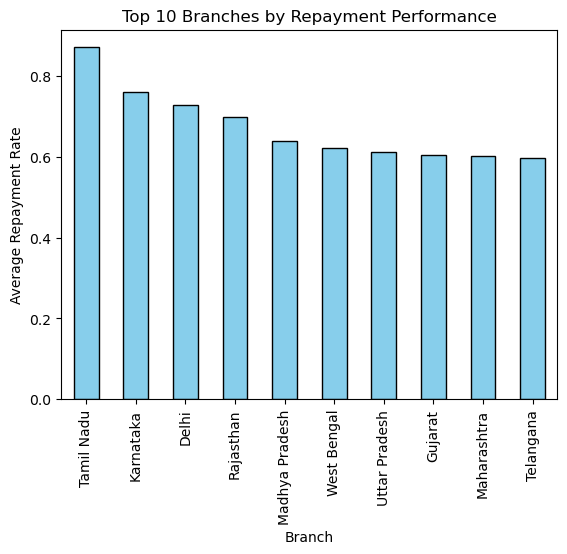

In [34]:
top_branches.plot(kind='bar', color ='skyblue',edgecolor ='black')
plt.title("Top 10 Branches by Repayment Performance")
plt.xlabel("Branch")
plt.ylabel("Average Repayment Rate")
plt.show()